In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt


In [2]:
class PredictiveModel(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PredictiveModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 64),
            nn.ReLU(),
            nn.Linear(64, state_dim)
        )

    def forward(self, state, action):
        x = torch.cat((state, action), dim=-1)
        return self.net(x)


In [3]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        return self.net(state)


In [4]:
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy = PolicyNetwork(state_dim, action_dim)
model = PredictiveModel(state_dim, action_dim)
optimizer_policy = optim.Adam(policy.parameters(), lr=0.001)
optimizer_model = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()


In [5]:
def train_hybrid(episodes=200):
    rewards = []
    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        for t in range(200):
            s_tensor = torch.FloatTensor(state)
            probs = policy(s_tensor)
            action = torch.multinomial(probs, 1).item()

            action_onehot = torch.zeros(action_dim)
            action_onehot[action] = 1.0

            next_state_pred = model(s_tensor.unsqueeze(0), action_onehot.unsqueeze(0)).detach()
            next_state_real, reward, done, truncated, _ = env.step(action)

            optimizer_model.zero_grad()
            pred = model(s_tensor.unsqueeze(0), action_onehot.unsqueeze(0))
            loss_model = criterion(pred, torch.tensor(next_state_real).unsqueeze(0))
            loss_model.backward()
            optimizer_model.step()

            optimizer_policy.zero_grad()
            advantage = torch.tensor(reward + 0.9 * (-abs(pred[0][2].item())), dtype=torch.float32)
            log_prob = torch.log(probs[action])
            loss_policy = -log_prob * advantage
            loss_policy.backward()
            optimizer_policy.step()

            total_reward += reward
            state = next_state_real
            if done or truncated:
                break
        rewards.append(total_reward)
    return rewards


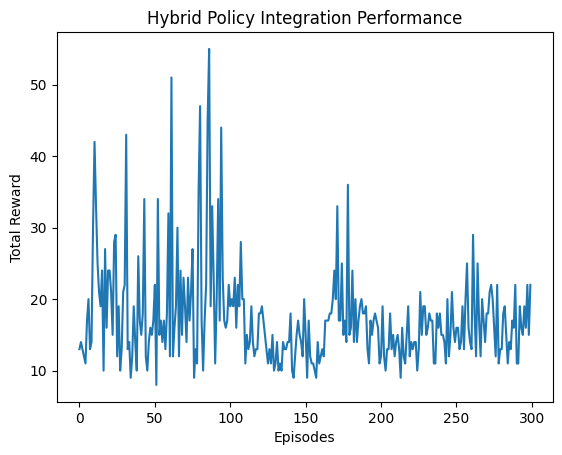

In [6]:
results = train_hybrid(300)
plt.plot(results)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Hybrid Policy Integration Performance")
plt.show()
